In [1]:
import os, json, random, re, shutil
from pathlib import Path
from collections import defaultdict
from itertools import count
from time import perf_counter
from math import sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [2]:
#### Create input gene list
RF_DIR = Path("../data/ml_output/mt_xgb_results_test_6/") # XGB results directory
EN_DIR = Path("../data/ml_output/mt_en_results_test_4") # EN results directory

In [3]:
def _pick_gene_stab_csv(dirpath: Path) -> Path:
    """
    Return the first CSV file whose name starts with 'gene_stability_scores'.
    Deterministic: picks the lexicographically first match.
    """
    dirpath = Path(dirpath)
    cands = sorted(dirpath.glob("gene_stability_scores*.csv"))
    if not cands:
        raise FileNotFoundError(f"No files starting with 'gene_stability_scores_' in {dirpath}")
    return cands[0]
RF_STAB_CSV = _pick_gene_stab_csv(RF_DIR)
EN_STAB_CSV = _pick_gene_stab_csv(EN_DIR)

print("RF file:", RF_STAB_CSV.name)
print("EN file:", EN_STAB_CSV.name)

xgb = pd.read_csv(RF_STAB_CSV)
en = pd.read_csv(EN_STAB_CSV)

assert {"gene","stability"}.issubset(xgb.columns), "RF table missing required columns"
assert {"gene","stability"}.issubset(en.columns), "EN table missing required columns"

RF file: gene_stability_scores.csv
EN file: gene_stability_scores.csv


In [4]:
OUTDIR_FS = Path("../data/features_label/features_panels/")
OUTDIR_FS.mkdir(parents=True, exist_ok=True)

Saved curves counts: ..\data\features_label\features_panels\stability_curves_counts_xgb_en_union_intersection.csv


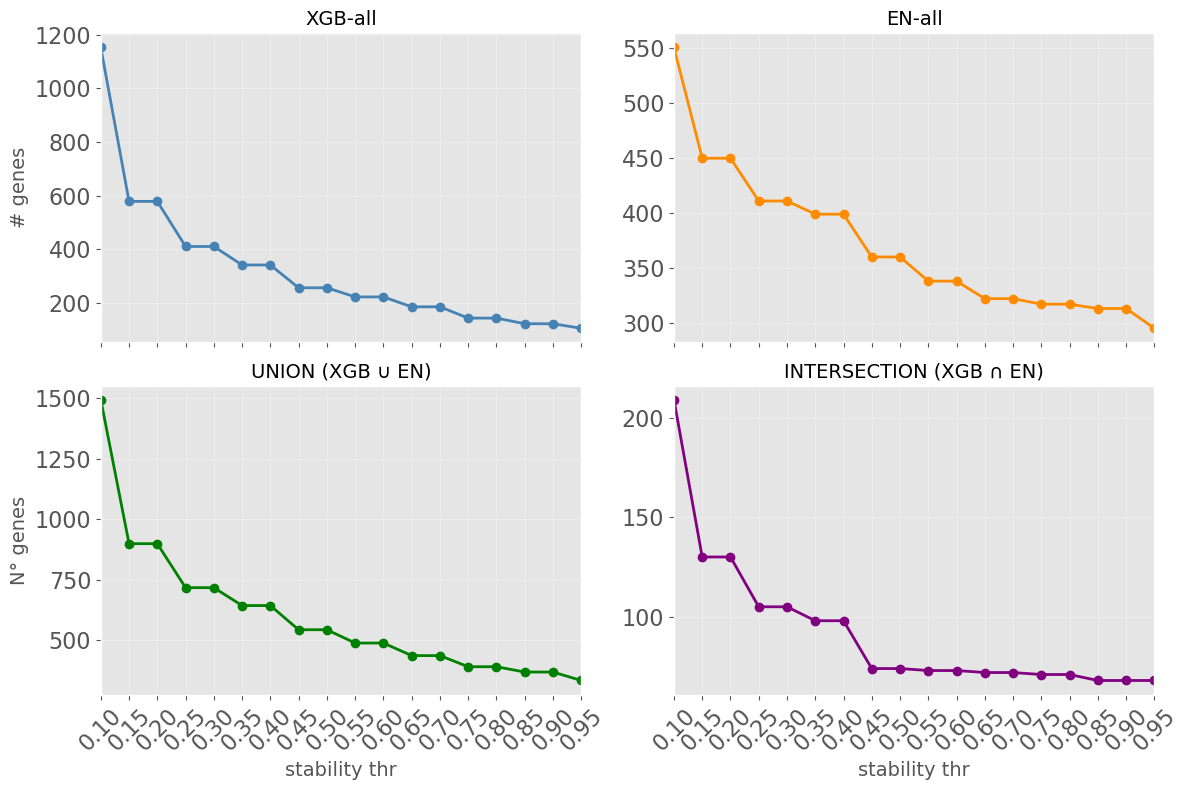

Saved figure: ..\data\features_label\features_panels\stability_curves_xgb_en_union_intersection.png


In [13]:
# Sanity checks
assert {"gene","stability"}.issubset(xgb.columns), "xgb must have ['gene','stability']"
assert {"gene","stability"}.issubset(en.columns), "en must have ['gene','stability']"

# Clean & index
xgb_clean = xgb[["gene", "stability"]].dropna().copy()
en_clean  = en[["gene", "stability"]].dropna().copy()
xgb_clean["stability"] = xgb_clean["stability"].astype(float)
en_clean["stability"]  = en_clean["stability"].astype(float)

# Threshold grid
thr_grid = np.round(np.arange(0.10, 0.951, 0.05), 2)

# Pre-extract (gene -> stability) as Series for fast filtering
xgb_s = xgb_clean.set_index("gene")["stability"]
en_s  = en_clean.set_index("gene")["stability"]

rows = []
for t in thr_grid:
    xgb_sel = set(xgb_s.index[xgb_s >= t])
    en_sel  = set(en_s.index[en_s >= t])
    union   = xgb_sel | en_sel
    inter   = xgb_sel & en_sel

    rows.append({
        "threshold": float(t),
        "xgb_n": len(xgb_sel),
        "en_n": len(en_sel),
        "union_n": len(union),
        "intersection_n": len(inter),
    })

curve_df = pd.DataFrame(rows)

# Save counts table
counts_csv = OUTDIR_FS / "stability_curves_counts_xgb_en_union_intersection.csv"
curve_df.to_csv(counts_csv, index=False)
print(f"Saved curves counts: {counts_csv}")

# ==== PLOT 2×2 ====
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

# Define colors
colors = {
    "xgb": "steelblue",
    "en": "darkorange",
    "union": "green",
    "inter": "purple",
}

# XGB
axes[0].plot(curve_df["threshold"], curve_df["xgb_n"], marker="o", linewidth=2, color=colors["xgb"])
axes[0].set_title("XGB-all", fontsize=14)
axes[0].set_ylabel("# genes", fontsize=14)
axes[0].grid(True, alpha=0.3)

# EN
axes[1].plot(curve_df["threshold"], curve_df["en_n"], marker="o", linewidth=2, color=colors["en"])
axes[1].set_title("EN-all", fontsize=14)
axes[1].grid(True, alpha=0.3)

# UNION
axes[2].plot(curve_df["threshold"], curve_df["union_n"], marker="o", linewidth=2, color=colors["union"])
axes[2].set_title("UNION (XGB ∪ EN)", fontsize=14)
axes[2].set_xlabel("stability thr", fontsize=14)
axes[2].set_ylabel("N° genes", fontsize=14)
axes[2].grid(True, alpha=0.3)

# INTERSECTION
axes[3].plot(curve_df["threshold"], curve_df["intersection_n"], marker="o", linewidth=2, color=colors["inter"])
axes[3].set_title("INTERSECTION (XGB ∩ EN)", fontsize=14)
axes[3].set_xlabel("stability thr", fontsize=14)
axes[3].grid(True, alpha=0.3)

# Cosmetics
for ax in axes:
    ax.set_xticks(thr_grid)
    ax.set_xlim(float(thr_grid.min()), float(thr_grid.max()))
    ax.tick_params(axis="x", rotation=45, labelsize=16)
    ax.tick_params(axis="y", labelsize=16)

fig.tight_layout()

# Save figure
fig_path = OUTDIR_FS / "stability_curves_xgb_en_union_intersection.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {fig_path}")


In [6]:
# --- Sanity checks ---
assert {"gene", "stability"}.issubset(xgb.columns), "xgb must have ['gene','stability']"
assert {"gene", "stability"}.issubset(en.columns),  "en must have ['gene','stability']"

# --- Main output folder ---
OUTDIR_FS = Path("../data/features_label/features_panels/")
OUTDIR_FS.mkdir(parents=True, exist_ok=True)

thr_list = [t / 100 for t in range(40, 91, 10)]
summary_rows = []

for t in thr_list:
    # --- Select genes at threshold t ---
    xgb_sel = set(xgb.loc[xgb["stability"] >= t, "gene"])
    en_sel  = set(en.loc[en["stability"]  >= t, "gene"])

    both      = xgb_sel & en_sel
    xgb_only  = xgb_sel - en_sel
    en_only   = en_sel  - xgb_sel
    union_set = xgb_sel | en_sel

    # --- Subdirectory for this threshold ---
    tag = f"{int(round(t * 100)):03d}"  
    thr_dir = OUTDIR_FS / f"thr_{tag}"
    thr_dir.mkdir(exist_ok=True)

    # --- Save gene panels in the subfolder ---
    pd.Series(sorted(xgb_only)).to_csv(thr_dir / f"genes_xgb_only_{tag}.txt", index=False, header=False)
    pd.Series(sorted(en_only)).to_csv(thr_dir / f"genes_en_only_{tag}.txt", index=False, header=False)
    pd.Series(sorted(both)).to_csv(thr_dir / f"genes_intersection_{tag}.txt", index=False, header=False)
    pd.Series(sorted(union_set)).to_csv(thr_dir / f"genes_union_{tag}.txt", index=False, header=False)

    # save full gene sets from each model
    pd.Series(sorted(xgb_sel)).to_csv(thr_dir / f"genes_xgb_all_{tag}.txt", index=False, header=False)
    pd.Series(sorted(en_sel)).to_csv(thr_dir / f"genes_en_all_{tag}.txt", index=False, header=False)

    # --- Add summary stats ---
    summary_rows.append({
        "threshold": t,
        "thr_dir": thr_dir.name,
        "xgb_only": len(xgb_only),
        "en_only": len(en_only),
        "intersection": len(both),
        "union": len(union_set),
        "xgb_total": len(xgb_sel),
        "en_total": len(en_sel),
    })

# --- Save global summary CSV ---
summary_df = pd.DataFrame(summary_rows).sort_values("threshold")
summary_csv = OUTDIR_FS / "panel_counts_by_threshold_040_090_step010.csv"
summary_df.to_csv(summary_csv, index=False)

# --- Print summary ---
print("\nPanels generated by threshold:")
for _, row in summary_df.iterrows():
    print(f"  - thr_{int(row['threshold']*100):03d}: "
          f"{int(row['union'])} genes in union "
          f"({int(row['intersection'])} in intersection) "
          f"[XGB={int(row['xgb_total'])}, EN={int(row['en_total'])}]")
print("\nSaved summary:", summary_csv)



Panels generated by threshold:
  - thr_040: 643 genes in union (98 in intersection) [XGB=342, EN=399]
  - thr_050: 543 genes in union (74 in intersection) [XGB=257, EN=360]
  - thr_060: 488 genes in union (73 in intersection) [XGB=223, EN=338]
  - thr_070: 436 genes in union (72 in intersection) [XGB=186, EN=322]
  - thr_080: 390 genes in union (71 in intersection) [XGB=144, EN=317]
  - thr_090: 368 genes in union (68 in intersection) [XGB=123, EN=313]

Saved summary: ..\data\features_label\features_panels\panel_counts_by_threshold_040_090_step010.csv


In [7]:
OUTDIR_CSV= Path("../data/features_label/subsets_x/")
OUTDIR_CSV.mkdir(parents=True, exist_ok=True)

In [ ]:
def save_subsets_by_threshold(
    thr: float,
    xgb: pd.DataFrame,
    en: pd.DataFrame,
    X_full: pd.DataFrame,
    outdir: Path = Path("../data/features_label/subsets_x/"),
    gene_col: str = "gene",
    score_col: str = "stability",
    file_prefix: str = "X_subset",
    save_gene_lists: bool = True,
):
    """
    Generate and save 6 subsets of X_full based on a stability threshold applied to genes
    selected from two models (xgb and en). Subsets created:
      - union, intersection, xgb_only, en_only, xgb_all, en_all

    Also saves gene lists (.txt) for each subset if save_gene_lists=True.

    Parameters
    ----------
    thr : float
        Stability threshold (e.g., 0.7).
    xgb, en : pd.DataFrame
        Must contain [gene_col, score_col].
    X_full : pd.DataFrame
        Full feature matrix (genes as columns).
    outdir : Path
        Directory where subset CSVs (and gene lists) will be saved.
    gene_col : str
        Column with gene identifiers.
    score_col : str
        Column with stability scores.
    file_prefix : str
        Prefix for the saved X subset CSV filenames.
    save_gene_lists : bool
        Whether to save per-panel gene lists (.txt).

    Returns
    -------
    summary_df : pd.DataFrame
        Table with panel name, #genes raw, #genes present in X, #missing, and output CSV path.
    """

    assert gene_col in xgb.columns and score_col in xgb.columns, "xgb missing required columns"
    assert gene_col in en.columns  and score_col in en.columns,  "en missing required columns"

    outdir.mkdir(parents=True, exist_ok=True)
    thr_tag = f"{thr:.2f}"

    # Ensure numeric stability, drop NaN, cast genes to str
    xgb_stable = pd.to_numeric(xgb[score_col], errors="coerce")
    en_stable  = pd.to_numeric(en[score_col], errors="coerce")

    xgb_sel = set(xgb.loc[xgb_stable >= thr, gene_col].dropna().astype(str))
    en_sel  = set(en.loc[en_stable  >= thr, gene_col].dropna().astype(str))

    # Build panels
    panels = {
        "union":        sorted(xgb_sel | en_sel),
        "intersection": sorted(xgb_sel & en_sel),
        "xgb_only":     sorted(xgb_sel - en_sel),
        "en_only":      sorted(en_sel - xgb_sel),
        "xgb_all":      sorted(xgb_sel), 
        "en_all":       sorted(en_sel),  
    }

    # Quick sanity: disjointness of *_only vs intersection
    assert len(set(panels["xgb_only"]).intersection(panels["intersection"])) == 0, "xgb_only overlaps intersection"
    assert len(set(panels["en_only"]).intersection(panels["intersection"])) == 0,  "en_only overlaps intersection"

    X_cols = set(map(str, X_full.columns))
    summary_rows = []

    print(f"[THR] Using threshold = {thr:.3f}")
    for name, genes in panels.items():
        # Save gene list (optional)
        if save_gene_lists:
            gene_txt = outdir / f"genes_{name}__thr{thr_tag}.txt"
            pd.Series(genes).to_csv(gene_txt, index=False, header=False)

        # Keep only genes present in X_full
        genes_in_X = [g for g in genes if g in X_cols]
        missing    = sorted(set(genes) - set(genes_in_X))

        if len(genes_in_X) == 0:
            print(f"[WARN] '{name}' panel has no genes in X; skipping X CSV.")
            summary_rows.append((name, len(genes), 0, len(missing), None))
            continue

        # Save X subset
        out_csv = outdir / f"{file_prefix}__{name}__thr{thr_tag}.csv"
        X_sub   = X_full.loc[:, genes_in_X].copy()
        X_sub.to_csv(out_csv)

        print(f"[SAVE] {name}: {len(genes_in_X)} columns -> {out_csv.name}  (shape={X_sub.shape})"
              + (f"  | missing in X: {len(missing)}" if missing else ""))

        summary_rows.append((name, len(genes), len(genes_in_X), len(missing), str(out_csv)))

    summary_df = pd.DataFrame(
        summary_rows,
        columns=["panel", "n_genes_raw", "n_genes_in_X", "n_missing", "X_csv_path"]
    ).sort_values("panel")

    print("\n[SUMMARY]")
    try:
        display(summary_df)
    except NameError:
        print(summary_df)

    return summary_df


In [11]:
X_PATH = Path("../data/features_label/processed_X/x_clean_no_scaled_no_imputation.csv")
X_full = pd.read_csv(X_PATH, index_col=0).astype("float32")
summary = save_subsets_by_threshold(thr=0.70, xgb=xgb_clean, en=en_clean, X_full=X_full)

[THR] Using threshold = 0.700
[SAVE] union: 436 columns -> X_subset__union__thr0.70.csv  (shape=(513, 436))
[SAVE] intersection: 72 columns -> X_subset__intersection__thr0.70.csv  (shape=(513, 72))
[SAVE] xgb_only: 114 columns -> X_subset__xgb_only__thr0.70.csv  (shape=(513, 114))
[SAVE] en_only: 250 columns -> X_subset__en_only__thr0.70.csv  (shape=(513, 250))
[SAVE] xgb_all: 186 columns -> X_subset__xgb_all__thr0.70.csv  (shape=(513, 186))
[SAVE] en_all: 322 columns -> X_subset__en_all__thr0.70.csv  (shape=(513, 322))

[SUMMARY]


,panel,n_genes_raw,n_genes_in_X,n_missing,X_csv_path
5,en_all,322,322,0,..\data\features_label\subsets_x\X_subset__en_...
3,en_only,250,250,0,..\data\features_label\subsets_x\X_subset__en_...
1,intersection,72,72,0,..\data\features_label\subsets_x\X_subset__int...
0,union,436,436,0,..\data\features_label\subsets_x\X_subset__uni...
4,xgb_all,186,186,0,..\data\features_label\subsets_x\X_subset__xgb...
2,xgb_only,114,114,0,..\data\features_label\subsets_x\X_subset__xgb...
